In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv("ChurnData.csv")
df.head()

,Unnamed: 0,tenure,age,address,income,ed,employ,equip,callcard,wireless,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [59]:
df=df.drop(columns=["Unnamed: 0"])

In [60]:
df.corr()["churn"].sort_values(ascending=False)

churn       1.000000
equip       0.275284
equipmon    0.255348
internet    0.254838
ebill       0.254838
ed          0.216112
wiremon     0.177483
wireless    0.174356
voice       0.142315
pager       0.124623
custcat     0.014839
tollmon     0.014356
callwait   -0.052885
tollten    -0.059482
logtoll    -0.070156
confer     -0.081361
income     -0.090790
lninc      -0.117459
cardmon    -0.177163
cardten    -0.228634
address    -0.260659
age        -0.287697
longmon    -0.292026
longten    -0.294906
callcard   -0.311451
loglong    -0.336869
employ     -0.337969
tenure     -0.376860
Name: churn, dtype: float64

In [61]:
df.shape

(200, 28)

In [62]:
df = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
df['churn'] = df['churn'].astype('int')
df

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0
...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1


In [72]:
X = df[['tenure', 'age', 'address', 'ed', 'employ', 'equip']]
X.head()

,tenure,age,address,ed,employ,equip
0,11.0,33.0,7.0,5.0,5.0,0.0
1,33.0,33.0,12.0,2.0,0.0,0.0
2,23.0,30.0,9.0,1.0,2.0,0.0
3,38.0,35.0,5.0,2.0,10.0,1.0
4,7.0,35.0,14.0,2.0,15.0,0.0


In [73]:
y = df['churn']
y[0:5] 

0    1
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

In [74]:
X_norm = StandardScaler().fit_transform(X)
X_norm

array([[-1.13518441, -0.62595491, -0.4588971 ,  1.6961288 , -0.58477841,
        -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.6433592 , -1.14437497,
        -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -1.42318853, -0.92053635,
        -0.85972695],
       ...,
       [-1.36680743, -0.7026181 , -0.16283445, -1.42318853, -0.02518185,
        -0.85972695],
       [-0.53296457, -0.85594447, -1.14970993,  0.91629947, -0.58477841,
        -0.85972695],
       [ 1.18104577,  0.67731925,  0.42929083, -0.6433592 ,  1.31784991,
         1.16316   ]], shape=(200, 6))

In [75]:
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=4)

## Logistic Regression Classifier modeling


In [76]:
LR = LogisticRegression().fit(X_train,y_train)

In [77]:
yhat = LR.predict(X_test)
yhat[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [78]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10]

array([[0.74574338, 0.25425662],
       [0.92640301, 0.07359699],
       [0.83450464, 0.16549536],
       [0.94595061, 0.05404939],
       [0.84282497, 0.15717503],
       [0.71406838, 0.28593162],
       [0.7705666 , 0.2294334 ],
       [0.90963952, 0.09036048],
       [0.26190613, 0.73809387],
       [0.94895073, 0.05104927]])

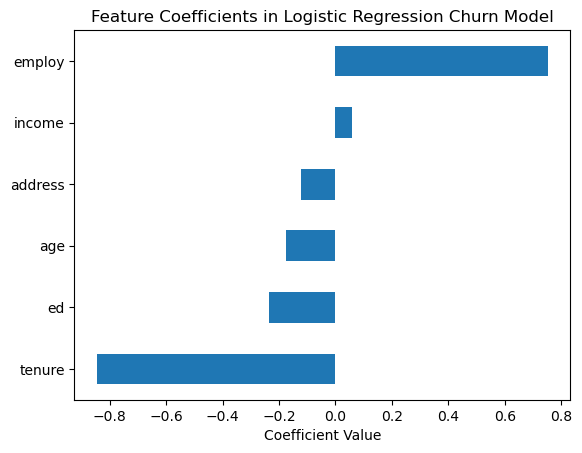

In [82]:
coefficients = pd.Series(LR.coef_[0], index=df.columns[:-2])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [84]:
log_loss(y_test, yhat_prob)

0.6258223046552053